In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

In [11]:
# Carregar a base Heart Disease
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Nomear as colunas
colunas = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Carregar para tratar valores nulos
df = pd.read_csv(url, names=colunas, na_values='?')

# Limpar linhas com valores ausentes
df = df.dropna()

# Transformar em Binário:
# 0 = Saudável, 1 ou mais = Presença de doença cardíaca
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

In [12]:
# Separar X e y
X = df.drop('target', axis=1)
y = df['target']

In [13]:
# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [14]:
# Padronizar os dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
# Criar e treinar o modelo
naive_bayes = GaussianNB()
naive_bayes.fit(X_train, y_train)

GaussianNB()

In [16]:
# Avaliar o modelo
y_pred = naive_bayes.predict(X_test)

print(f"Acurácia com Naive Bayes: {accuracy_score(y_test, y_pred):.2%}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=['Saudável', 'Doente']))

Acurácia com Naive Bayes: 87.78%

Relatório de Classificação:
              precision    recall  f1-score   support

    Saudável       0.88      0.90      0.89        48
      Doente       0.88      0.86      0.87        42

    accuracy                           0.88        90
   macro avg       0.88      0.88      0.88        90
weighted avg       0.88      0.88      0.88        90



In [17]:
# --- GRÁFICO 1: Matriz de Confusão ---
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)

<Figure size 600x400 with 0 Axes>

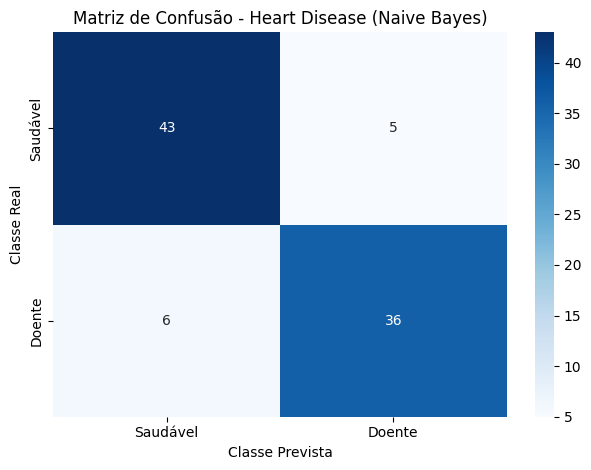

In [18]:
# Criando o gráfico de calor (heatmap) para os acertos e erros
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Saudável', 'Doente'],
            yticklabels=['Saudável', 'Doente'])

plt.title('Matriz de Confusão - Heart Disease (Naive Bayes)')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.tight_layout()
plt.show()